In [15]:
import numpy as np
import pandas as pd

In [16]:
df = pd.read_csv('placement.csv');

In [17]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [18]:
df.shape

(100, 4)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [20]:
df = df.iloc[:,1:]

In [21]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [22]:
import matplotlib.pyplot as plt

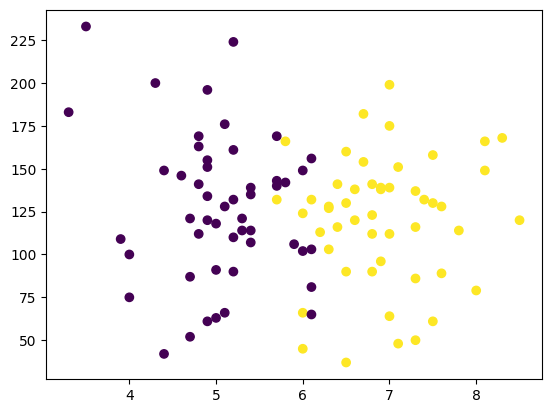

In [26]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [28]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [29]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [30]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [33]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [34]:
from sklearn.preprocessing import StandardScaler

In [36]:
scalar = StandardScaler()

In [37]:
x_train = scalar.fit_transform(x_train)
x_train

array([[ 1.1420671 , -1.89652792],
       [-0.69028164,  2.55618981],
       [ 0.88030299,  1.30226355],
       [ 0.88030299, -0.30992735],
       [-0.60302694, -0.25874669],
       [-0.69028164,  0.94399891],
       [ 0.00775597, -0.56583067],
       [ 0.53128419, -0.1052047 ],
       [-0.77753634,  0.09951796],
       [-0.95204575, -0.1052047 ],
       [-1.03930045,  0.99517957],
       [ 0.96755769,  0.68809559],
       [-0.95204575,  0.68809559],
       [ 0.79304829,  0.38101161],
       [ 1.1420671 , -0.97527598],
       [-1.21380985,  0.56014393],
       [-0.25400813,  0.40660194],
       [ 0.26952008, -0.54024034],
       [ 0.26952008,  0.09951796],
       [ 0.09501068,  0.20187928],
       [ 1.3165765 , -1.61503427],
       [ 1.2293218 ,  0.20187928],
       [ 0.35677478, -0.20756602],
       [-0.16675343,  1.07195057],
       [-0.95204575,  0.79045692],
       [ 0.44402948,  0.91840857],
       [ 1.75285001, -1.1544083 ],
       [ 0.79304829, -0.71937266],
       [ 0.70579359,

In [38]:
x_test = scalar.transform(x_test)
x_test

array([[-0.86479105, -0.84732432],
       [ 0.53128419,  0.35542127],
       [-1.38831926, -2.10125058],
       [-1.03930045,  1.14872156],
       [-0.60302694, -0.07961437],
       [ 0.61853889,  1.48139587],
       [ 1.1420671 ,  0.32983094],
       [ 0.00775597, -2.02447958],
       [ 1.57834061, -0.25874669],
       [ 0.00775597,  0.63691492]])

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
clf = LogisticRegression()

In [41]:
# model training
clf.fit(x_train,y_train)

LogisticRegression()

In [46]:
y_pred=clf.predict(x_test)

In [47]:
y_test

,placement
25,0
48,1
96,0
75,0
2,0
97,1
61,1
10,1
55,1
33,0


In [48]:
from sklearn.metrics import accuracy_score

In [49]:
accuracy_score(y_test,y_pred)

0.8

In [50]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

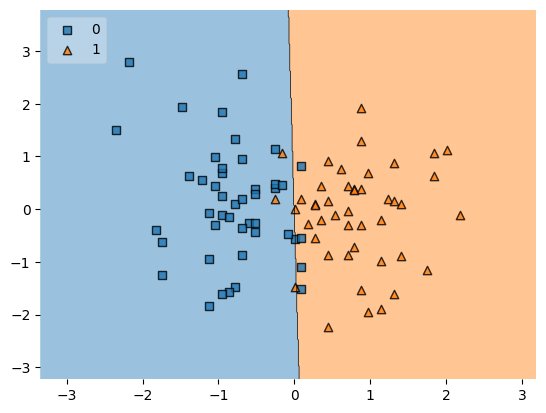

In [52]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [53]:
import pickle

In [54]:
pickle.dump(clf, open('model.pkl','wb'))